# **Train Model**

In [25]:
import numpy as np
import cv2
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
CSVPATH = PROJECT_ROOT / "feature_engineering" / "mango_defect.csv"

In [26]:
fruits = pd.read_csv(CSVPATH)
fruits

,image_id,image,brightness_threshold,defect_percentage,number_of_defects,yellow_ratio,largest_defect_ratio,mean_defect_ratio,aspect_ratio,circularity,solidity,grade
0,NDM_M1 (1),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,22,0.123682,4,70.826156,0.000532,0.000309,2.181001,0.599319,0.959423,NDM_M1
1,NDM_M1 (10),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,18,0.539316,16,68.416842,0.000828,0.000337,0.501448,0.624411,0.960154,NDM_M1
2,NDM_M1 (100),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.150871,6,72.215850,0.000532,0.000251,0.461047,0.572685,0.950932,NDM_M1
3,NDM_M1 (101),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,21,0.130499,4,83.939243,0.000451,0.000326,2.189017,0.600500,0.957417,NDM_M1
4,NDM_M1 (102),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,21,0.122899,4,83.936687,0.000435,0.000307,0.456509,0.602001,0.958129,NDM_M1
...,...,...,...,...,...,...,...,...,...,...,...,...
537,NDM_M3 (95),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.684021,15,0.125457,0.001503,0.000456,0.507673,0.684655,0.983823,NDM_M3
538,NDM_M3 (96),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,31,0.097857,4,0.322886,0.000499,0.000245,1.981343,0.678619,0.982263,NDM_M3
539,NDM_M3 (97),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,30,0.101622,4,0.358533,0.000514,0.000254,0.504391,0.681095,0.982601,NDM_M3
540,NDM_M3 (98),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.075858,4,0.043647,0.000419,0.000190,1.809908,0.462822,0.952613,NDM_M3


In [27]:
grade_map = {"NDM_M1": "Class II",
             "NDM_M2": "Class I",
             "NDM_M3": "Extra Class"}

grades = fruits["grade"].map(grade_map)
fruits["grade"] = grades

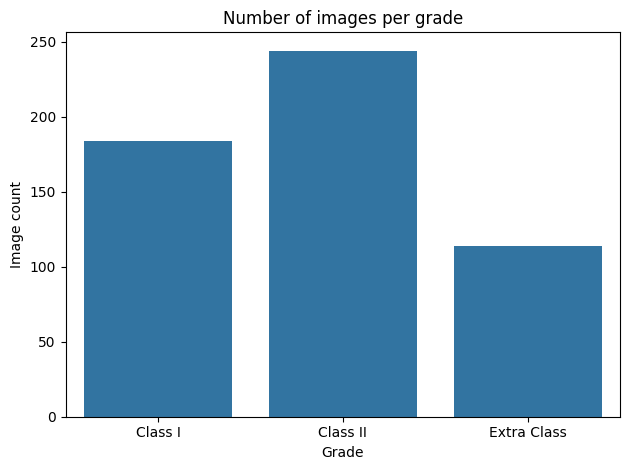

grade
Class I        184
Class II       244
Extra Class    114
Name: count, dtype: int64


In [24]:
grade_counts = fruits["grade"].value_counts().sort_index()

sns.countplot(data=fruits, x="grade", order=grade_counts.index)
plt.title("Number of images per grade")
plt.xlabel("Grade")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()

print(grade_counts)

In [30]:
skf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

X = fruits.drop(columns=["grade"])
y = fruits["grade"]
groups = fruits["image_id"]

folds = []
for fold_number, (train_idx, val_idx) in enumerate(
    skf.split(X, y, groups=groups),
    start=1,
):
    train_data = fruits.iloc[train_idx].reset_index(drop=True)
    validation_data = fruits.iloc[val_idx].reset_index(drop=True)
    folds.append((train_data, validation_data))

    print(
        f"Fold {fold_number}: "
        f"train={len(train_data)}, validation={len(validation_data)}"
    )
    print("Train classes:", train_data["grade"].value_counts().to_dict())
    print("Validation classes:", validation_data["grade"].value_counts().to_dict())

Fold 1: train=433, validation=109
Train classes: {'Class II': 195, 'Class I': 147, 'Extra Class': 91}
Validation classes: {'Class II': 49, 'Class I': 37, 'Extra Class': 23}
Fold 2: train=434, validation=108
Train classes: {'Class II': 195, 'Class I': 148, 'Extra Class': 91}
Validation classes: {'Class II': 49, 'Class I': 36, 'Extra Class': 23}
Fold 3: train=434, validation=108
Train classes: {'Class II': 195, 'Class I': 147, 'Extra Class': 92}
Validation classes: {'Class II': 49, 'Class I': 37, 'Extra Class': 22}
Fold 4: train=433, validation=109
Train classes: {'Class II': 195, 'Class I': 147, 'Extra Class': 91}
Validation classes: {'Class II': 49, 'Class I': 37, 'Extra Class': 23}
Fold 5: train=434, validation=108
Train classes: {'Class II': 196, 'Class I': 147, 'Extra Class': 91}
Validation classes: {'Class II': 48, 'Class I': 37, 'Extra Class': 23}
